In [1]:
#| label: setup
#| include: false

from pathlib import Path
import sys
import importlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / "analyst").exists() and (candidate / "config").exists():
            return candidate
    raise RuntimeError("Repo root not found from notebook working directory.")

_root = find_repo_root(Path.cwd())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from analyst.table_formatting import display_analysis_table
import analyst.plot_utils as pu
from analyst import model_5600_train_valid_analysis as h

pu = importlib.reload(pu)
h = importlib.reload(h)
pu.apply_theme()

MODEL_ID = "lgbm_solusdt_s_fw60_2101_2605"

CQ_COLORS = {
    "blue": "#1696d2",
    "black": "#000000",
    "gray_dark": "#353535",
    "gray": "#696969",
    "gray_light": "#d2d2d2",
    "yellow": "#fdbf11",
    "orange": "#f15a24",
    "red": "#ec008b",
}
SEGMENT_COLORS = {"train": CQ_COLORS["blue"], "valid": CQ_COLORS["orange"]}

pred_df = h.load_cv_predictions(_root, MODEL_ID)
fold_metrics_df = h.load_fold_metrics(_root, MODEL_ID)
split_metrics_df = h.split_summary_metrics(pred_df)
residual_df = h.residual_summary(pred_df)
decile_df = h.decile_summary(pred_df, n_bins=10)
mono_df = h.monotonicity_summary(decile_df)
comp_df = h.decile_comparison(decile_df)
train_rank_df = h.fold_rank_metrics(pred_df, segment="train")
valid_rank_df = h.fold_rank_metrics(pred_df, segment="valid")
fold_rank_both_df = pd.concat([train_rank_df, valid_rank_df], ignore_index=True).sort_values(["fold", "segment"]).reset_index(drop=True)
valid_fold_decile_df = h.fold_decile_summary(pred_df, segment="valid", n_bins=10)
manifest = h.load_manifest(_root, MODEL_ID)
metadata_snapshot = h.load_metadata_snapshot(_root, MODEL_ID)
search_summary_df = h.search_summary_table(_root, MODEL_ID)
fold_window_df = h.fold_window_table(_root, MODEL_ID)
scatter_df = h.scatter_sample(pred_df, n_per_segment=3500, seed=42)
comment_lines = h.commentary_lines(split_metrics_df, fold_metrics_df)
TARGET_COL = metadata_snapshot["target_col"]
PRED_COL = metadata_snapshot["pred_col"]
DIRECTION_LABEL = "long" if TARGET_COL.startswith("long_") else "short" if TARGET_COL.startswith("short_") else "model"

top_bottom_df = mono_df[["segment", "top_minus_bottom", "top_div_bottom"]].copy()
bottom_targets = decile_df.groupby("segment")["target_mean"].min().rename("bottom_decile_target")
top_targets = decile_df.groupby("segment")["target_mean"].max().rename("top_decile_target")
top_bottom_df = top_bottom_df.merge(bottom_targets, on="segment").merge(top_targets, on="segment")

def build_decile_summary(segment: str) -> pd.DataFrame:
    seg_dec = decile_df.loc[decile_df["segment"] == segment].copy().sort_values("decile")
    seg_split = split_metrics_df.loc[split_metrics_df["segment"] == segment].iloc[0]
    avg_target = float(seg_split["target_mean"])
    avg_pred = float(seg_split["pred_mean"])
    rows = [{
        "bucket": "ALL",
        "rows": int(seg_split["rows"]),
        "pred_mean": avg_pred,
        "target_mean": avg_target,
        "target_vs_all_abs": 0.0,
        "target_vs_all_ratio": 1.0,
    }]
    for row in seg_dec.itertuples(index=False):
        rows.append({
            "bucket": f"D{int(row.decile)}",
            "rows": int(row.rows),
            "pred_mean": float(row.pred_mean),
            "target_mean": float(row.target_mean),
            "target_vs_all_abs": float(row.target_mean - avg_target),
            "target_vs_all_ratio": float(row.target_mean / avg_target),
        })
    return pd.DataFrame(rows)

train_decile_summary_df = build_decile_summary("train")
valid_decile_summary_df = build_decile_summary("valid")
date_span = f"{pred_df['open_time'].min():%Y-%m-%d} - {pred_df['open_time'].max():%Y-%m-%d}"


## Cel

Ez a riport a `2101-2605` champion modell train-valid viselkedeset magyarazza el.
A cel nem csak a vegso metrikak bemutatasa, hanem annak ellenorzese is, hogy a jel
a 2023-01 es 2026-05 kozotti walk-forward idoszakban mennyire stabil pontbecsleskent
es mennyire eros rangsorolo score-kent.


## Modell Es Validacios Setup

**Forrasok.** `manifest.json`, `metadata.json`, `search/search_best.json`,
`sample_train_valid.parquet`, valamint a riporthoz keszitett `cv_predictions.parquet`.

**Modszer.** A train-valid elemzes a meglevo artifact sample-ekre es a helper altal
eloallitott foldonkenti CV predikciokra epul. A notebook nem modosit modellt,
csak visszaolvassa es osszegzi a mar letrejott train-valid struktura eredmenyeit.


In [2]:
#| label: tbl-model-manifest
#| tbl-cap: "A modell artifact es validacios setup legfontosabb jellemzoi"

manifest_df = pd.DataFrame([{
    "model_id": manifest["model_id"],
    "display_name": manifest.get("display_name"),
    "family": manifest["family"],
    "trainer": manifest["trainer"],
    "target_name": manifest["target_name"],
    "sample_id": manifest["sampling"]["sample_id"],
    "row_stride": manifest["sampling"]["row_stride"],
    "pipeline_status": manifest["pipeline_status"],
    "updated_at": manifest["updated_at"],
}])
display_analysis_table(manifest_df)


model_id,display_name,family,trainer,target_name,sample_id,row_stride,pipeline_status,updated_at
lgbm_solusdt_s_fw60_2101_2605,SOL Short LightGBM Champion 2101-2605,lightgbm,lightgbm_regression,short_mfe_fw60,solusdt_fw60_2101_2605,60,search_done,2026-06-20T13:27:23.919566+00:00


In [3]:
#| label: tbl-analysis-scope
#| tbl-cap: "A riport altal lefedett idoszak es walk-forward beallitasok"

scope_df = pd.DataFrame([{
    "analysis_period": date_span,
    "train_months": manifest["sampling"].get("train_months"),
    "valid_months": manifest["sampling"].get("valid_months"),
    "shift_months": manifest["sampling"].get("shift_months"),
    "n_folds": manifest["sampling"].get("n_folds"),
}])
display_analysis_table(scope_df)


analysis_period,train_months,valid_months,shift_months,n_folds
2023-01-01 - 2026-05-31,9,8,8,4


A target a manifestben megadott `*_mfe_fw60`, vagyis a kovetkezo 60 percben kialakulo favorable
excursion log-return alakban.

Fontos skala-megjegyzes:

- itt a target log-return, ezert a "nincs valtozas" pontja `0`, nem `1`;
- ha nyers aranyt neznank, ott lenne a "nincs valtozas" ertek `1`;
- vagyis egy `0.02` target kb. `exp(0.02) - 1 ~= 2.02%` favorable elmozdulasnak felel meg.


In [4]:
#| label: tbl-fold-schema
#| tbl-cap: "Walk-forward fold sema - train es validacios idoszakok"

display_analysis_table(fold_window_df)


fold_id,train_start,train_end,train_months,valid_start,valid_end,valid_months
1,2023-01-01,2023-09-30,9,2023-10-01,2024-05-31,8
2,2023-09-01,2024-05-31,9,2024-06-01,2025-01-31,8
3,2024-05-01,2025-01-31,9,2025-02-01,2025-09-30,8
4,2025-01-01,2025-09-30,9,2025-10-01,2026-05-31,8


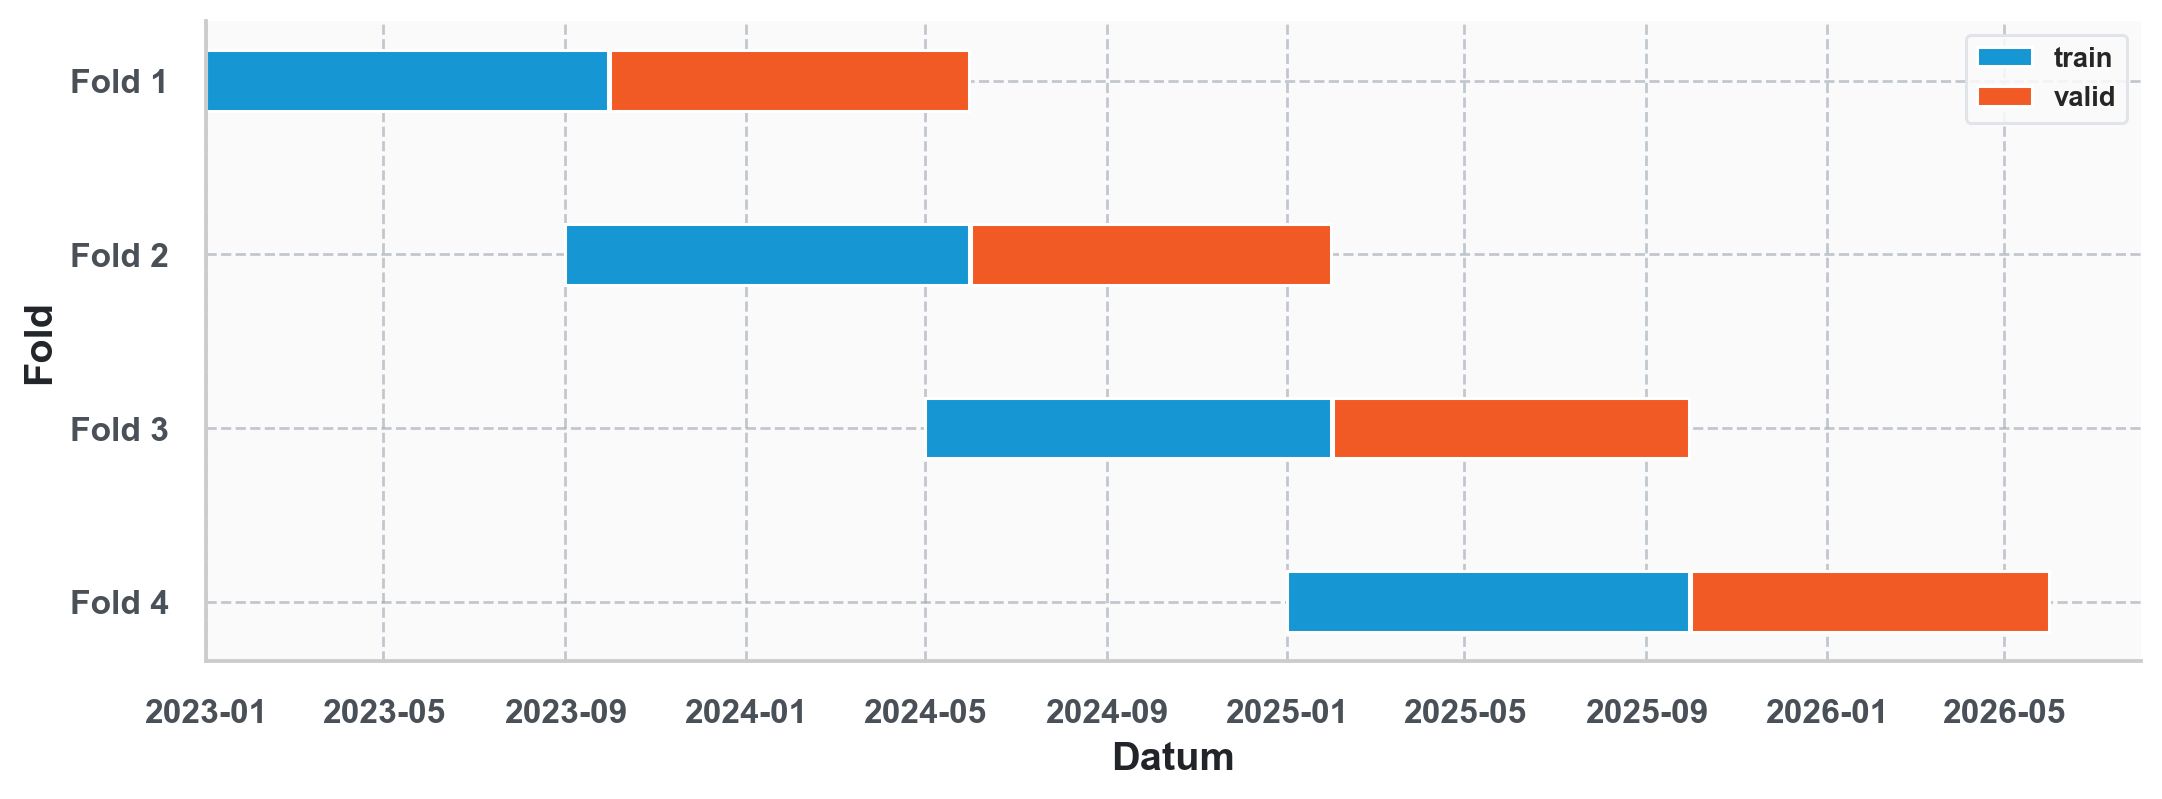

In [5]:
#| label: fig-fold-timeline
#| fig-cap: "Walk-forward foldok idobeli elhelyezese"
#| fig-alt: "Vizszintes savdiagram a train es valid idoszakokkal foldonkent."

fig, ax = plt.subplots(figsize=(10, 3.8))
y_positions = np.arange(len(fold_window_df))[::-1]
for y, row in zip(y_positions, fold_window_df.itertuples(index=False)):
    train_start = pd.Timestamp(row.train_start)
    train_end = pd.Timestamp(row.train_end)
    valid_start = pd.Timestamp(row.valid_start)
    valid_end = pd.Timestamp(row.valid_end)
    ax.barh(y, train_end - train_start, left=train_start, height=0.35, color=CQ_COLORS["blue"], label="train" if y == y_positions[0] else "")
    ax.barh(y, valid_end - valid_start, left=valid_start, height=0.35, color=CQ_COLORS["orange"], label="valid" if y == y_positions[0] else "")
ax.set_yticks(y_positions)
ax.set_yticklabels([f"Fold {x}" for x in fold_window_df["fold_id"]])
ax.set_xlabel("Datum")
ax.set_ylabel("Fold")
ax.legend()
plt.tight_layout()
plt.show()


## Fold-Szintu Es Osszesitett Pontbecslo Kep

Ebben a blokkban a regresszios pontbecslo oldalt nezzuk: mennyire marad egyben a
train-valid hiba, mennyire zajos a predikcio-target kapcsolat, es latszik-e eros rezsimfugges.


In [6]:
#| label: tbl-search-summary
#| tbl-cap: "Best search trial rovid osszefoglaloja"

display_analysis_table(search_summary_df)


trial_no,objective_score,mean_top10_lift,std_top10_lift,mean_spearman_rho,mean_decile_monotonicity,mean_valid_rmse,folds_in_search_summary
65,-0.003,0.003,0.000,0.307,0.972,0.008,4


In [7]:
#| label: tbl-fold-metrics
#| tbl-cap: "Fold-szintu train-valid regresszios metrikak a teljes CV-ben"

display_analysis_table(fold_metrics_df)


fold,best_iteration,train_rmse,valid_rmse,train_mae,valid_mae,train_r2,valid_r2,train_n,valid_n
1,1166.00%,0.007,0.009,0.004,0.005,0.120,0.105,24068,5856
2,1366.00%,0.008,0.007,0.004,0.004,0.123,0.146,24044,5880
3,966.00%,0.008,0.006,0.004,0.004,0.125,0.122,24116,5808
4,3000.00%,0.007,0.008,0.004,0.004,0.135,0.097,24096,5832


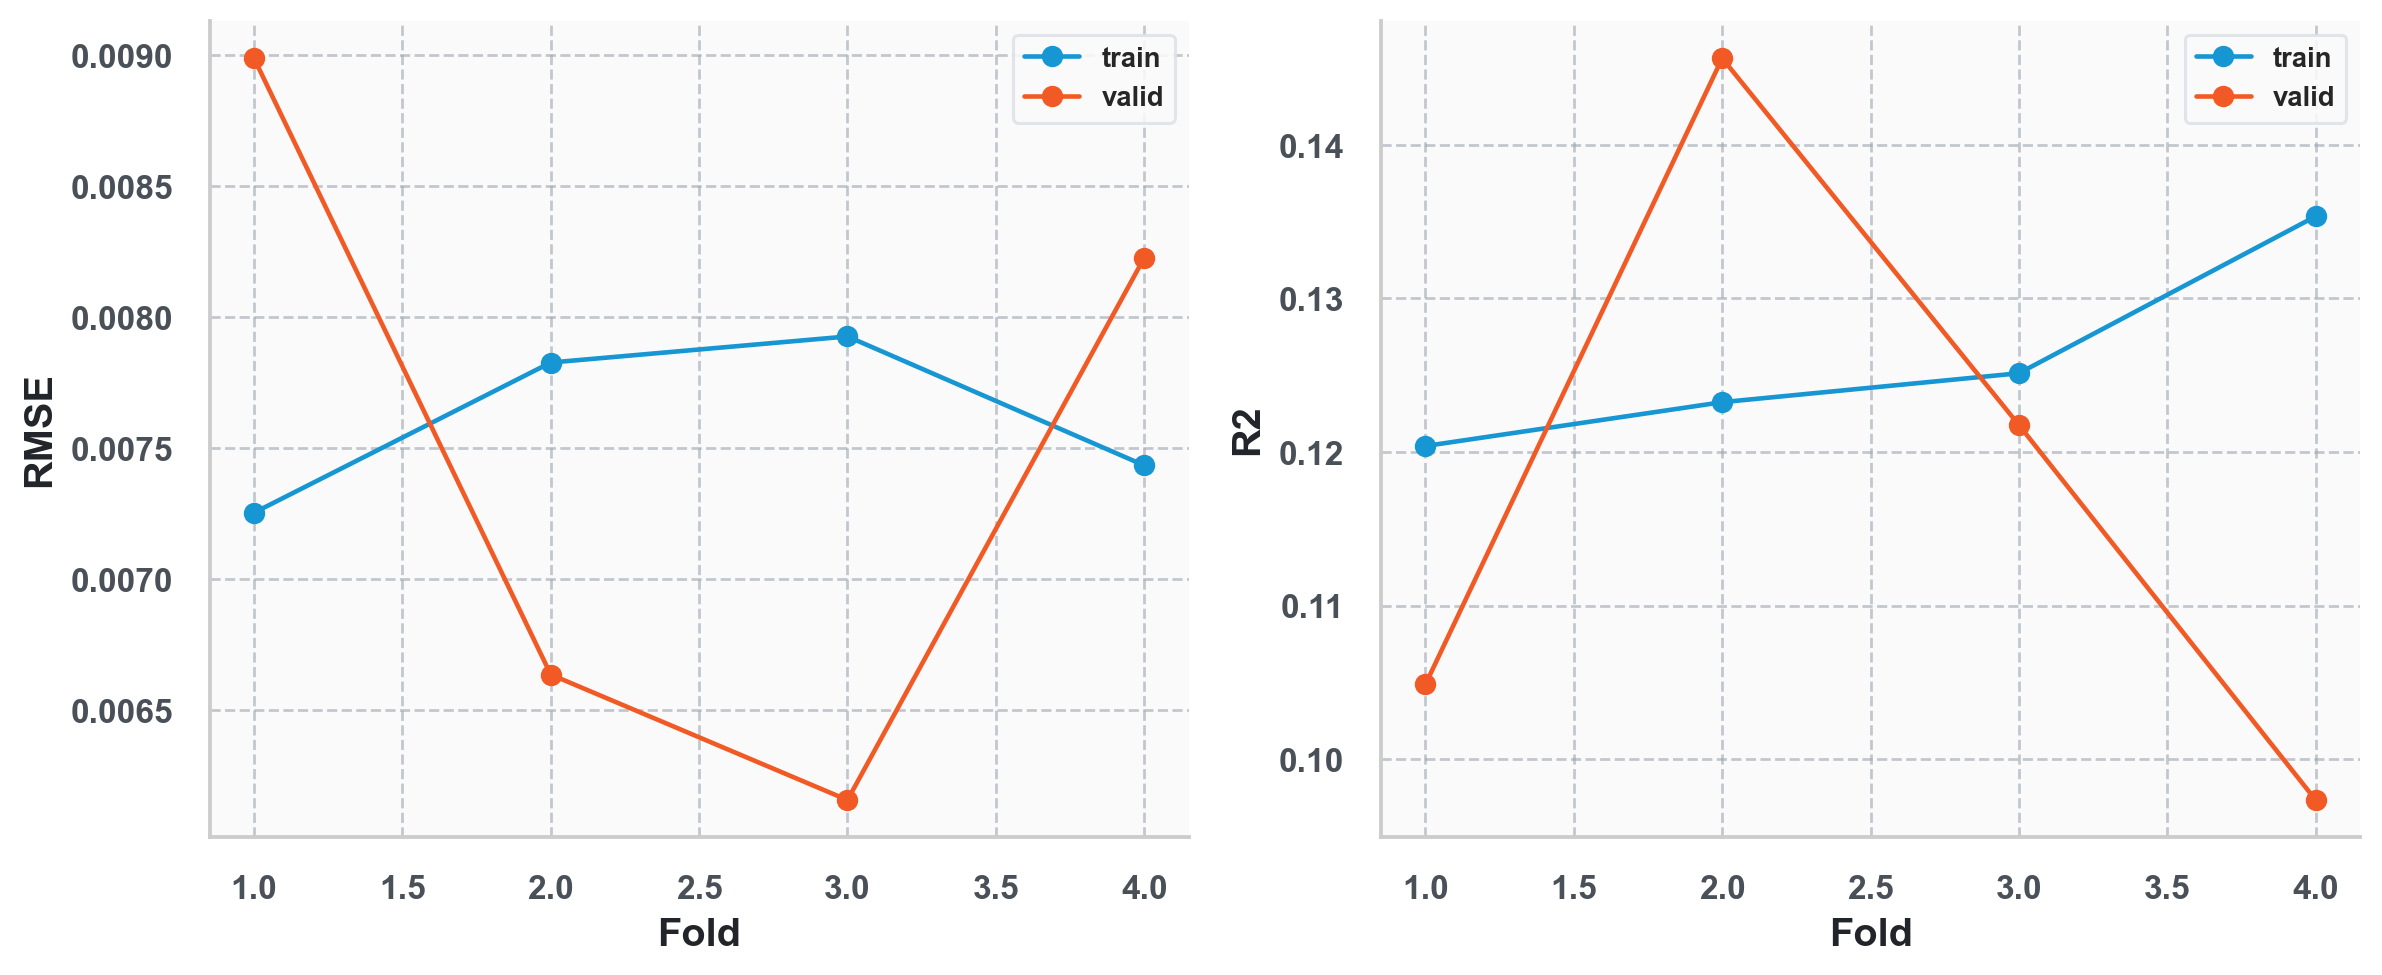

In [8]:
#| label: fig-fold-metrics
#| fig-cap: "Foldonkenti train-valid RMSE es R2"

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
fm = fold_metrics_df.copy()
axes[0].plot(fm["fold"], fm["train_rmse"], marker="o", color=CQ_COLORS["blue"], label="train")
axes[0].plot(fm["fold"], fm["valid_rmse"], marker="o", color=CQ_COLORS["orange"], label="valid")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("RMSE")
axes[0].legend()
axes[1].plot(fm["fold"], fm["train_r2"], marker="o", color=CQ_COLORS["blue"], label="train")
axes[1].plot(fm["fold"], fm["valid_r2"], marker="o", color=CQ_COLORS["orange"], label="valid")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("R2")
axes[1].legend()
plt.tight_layout()
plt.show()


In [9]:
#| label: fold-metric-commentary
#| echo: false

lines = "\n".join([f"- {line}" for line in comment_lines])
display(Markdown("**Interpretacio.**\n\n" + lines))


**Interpretacio.**

- A validációs átlagos RMSE `0.0076`, a train oldali `0.0076`; a két oldal közel van egymáshoz, ezért a modell nem látszik durván overfiteltnek.
- A validációs R² csak `0.123`, ezért a modell jelet fog, de a folytonos target varianciájának jelentős része továbbra is megmagyarázatlan.
- A legjobb valid fold a `3`, a leggyengébb a `1`; tehát a teljesítmény szemmel láthatóan rezsim- és időszakfüggő.
- A predikció-target kapcsolat pozitív, de zajos. Ez használható rangsorolási jellegű kimenetre, de nem tekinthető pontos pontbecslő regressziónak.

In [10]:
#| label: tbl-split-metrics
#| tbl-cap: "Osszesitett train es valid regresszios metrikak"

display_analysis_table(split_metrics_df)


segment,rows,pred_mean,target_mean,bias,rmse,mae,target_std,r2,corr,rmse_vs_target_std
train,96324,-0.006,-0.006,-0.000,0.008,0.004,0.008,0.127,0.356,0.935
valid,23376,-0.006,-0.006,0.000,0.008,0.004,0.008,0.123,0.351,0.936


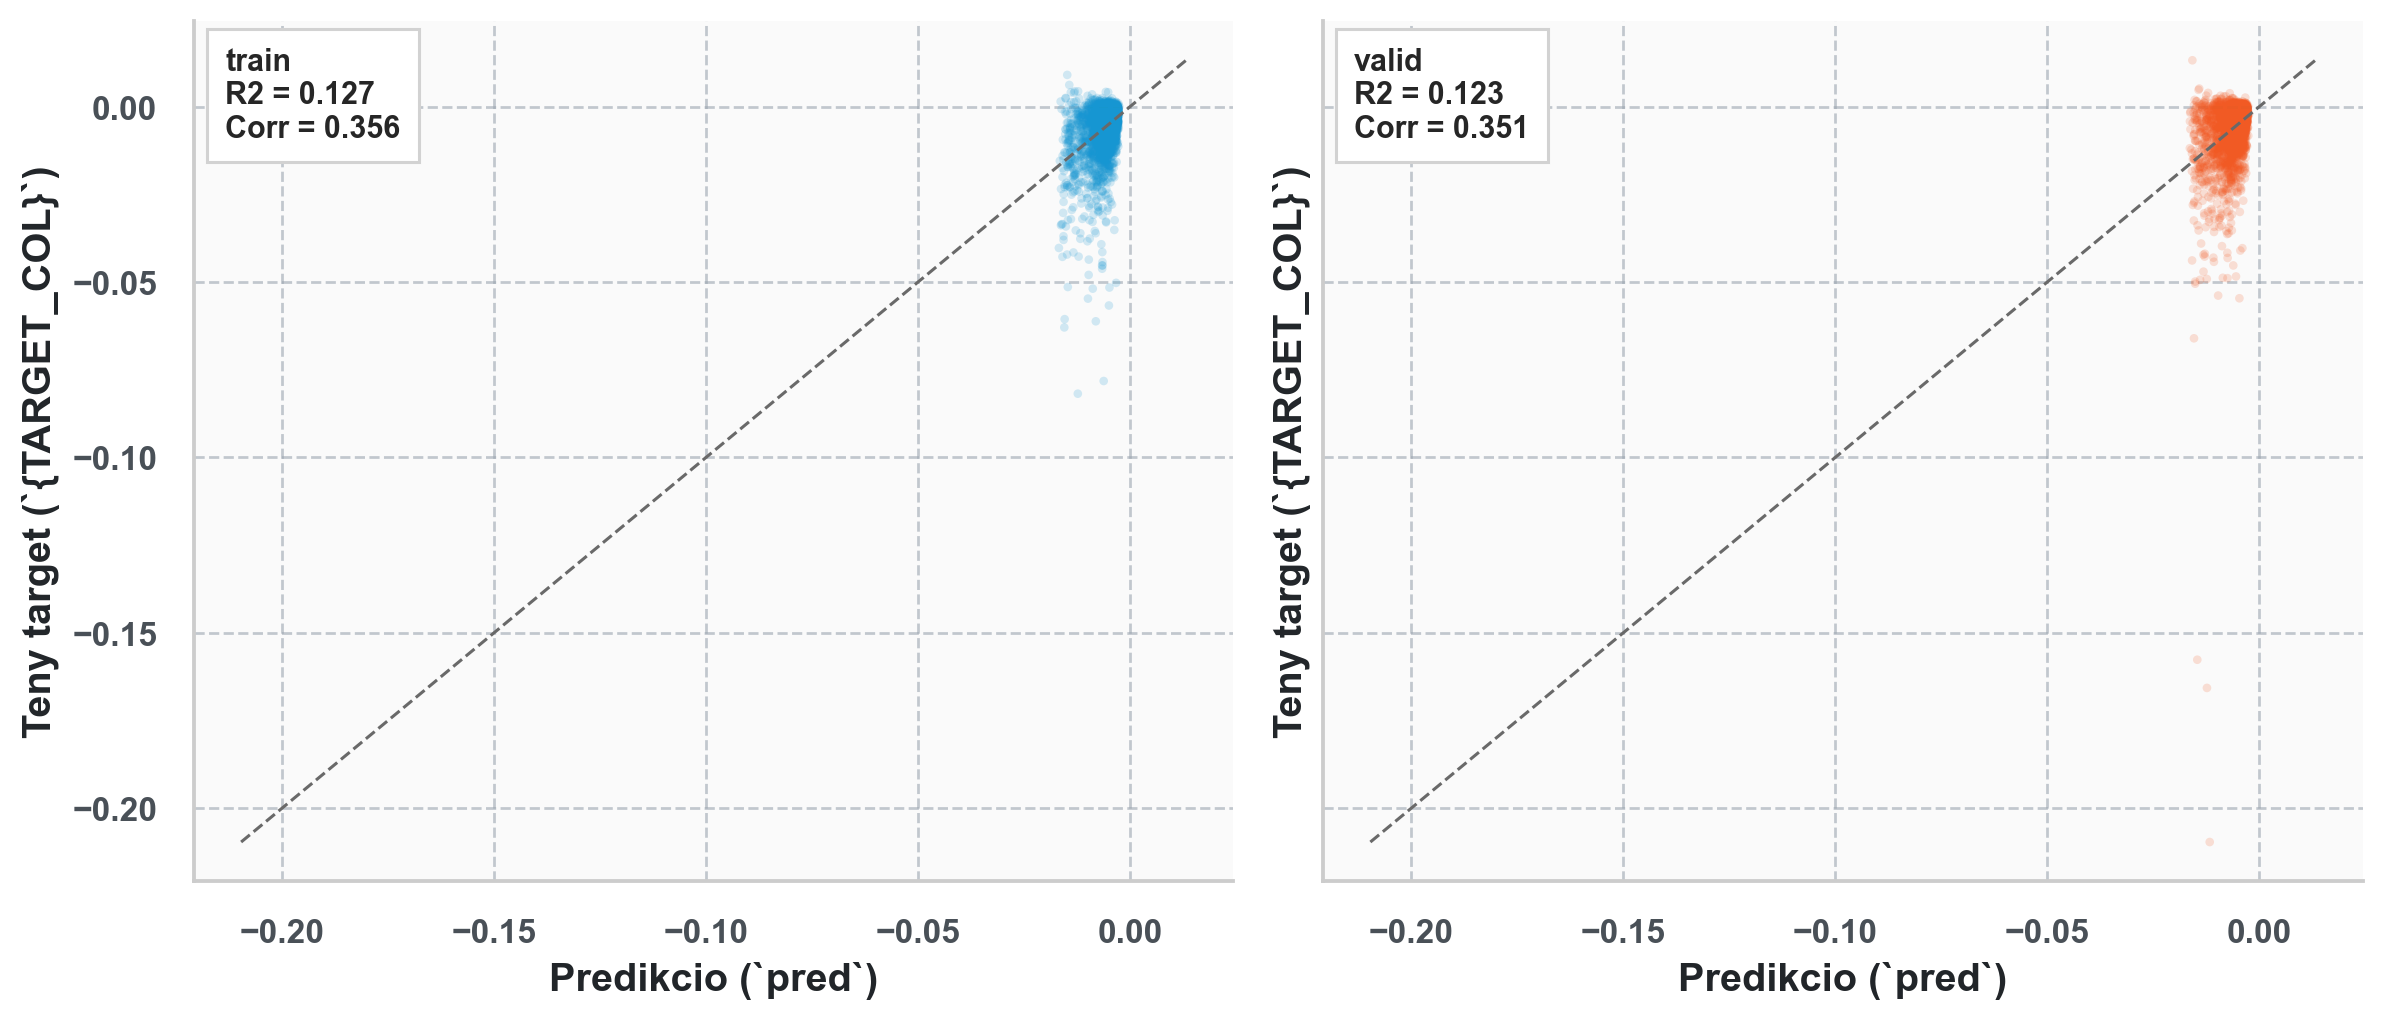

In [11]:
#| label: fig-train-valid-scatter
#| fig-cap: "Predikcio es target kapcsolata train es valid mintan"
#| fig-alt: "Ketpaneles scatterabra, idealis atloval."

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)
lo = min(scatter_df["pred"].min(), scatter_df["target"].min())
hi = max(scatter_df["pred"].max(), scatter_df["target"].max())
for ax, segment in zip(axes, ["train", "valid"]):
    sub = scatter_df.loc[scatter_df["segment"] == segment]
    row = split_metrics_df.loc[split_metrics_df["segment"] == segment].iloc[0]
    ax.scatter(sub["pred"], sub["target"], s=8, alpha=0.18, color=SEGMENT_COLORS[segment], edgecolors="none")
    ax.plot([lo, hi], [lo, hi], linestyle="--", color=CQ_COLORS["gray"], linewidth=1)
    ax.set_xlabel("Predikcio (`pred`)")
    ax.set_ylabel(f"Teny target (`{{TARGET_COL}}`)")
    ax.text(0.03, 0.97, f"{segment}\nR2 = {row['r2']:.3f}\nCorr = {row['corr']:.3f}", transform=ax.transAxes, va="top", ha="left", fontsize=10, bbox={"facecolor": "white", "edgecolor": CQ_COLORS["gray_light"], "pad": 6})
plt.tight_layout()
plt.show()


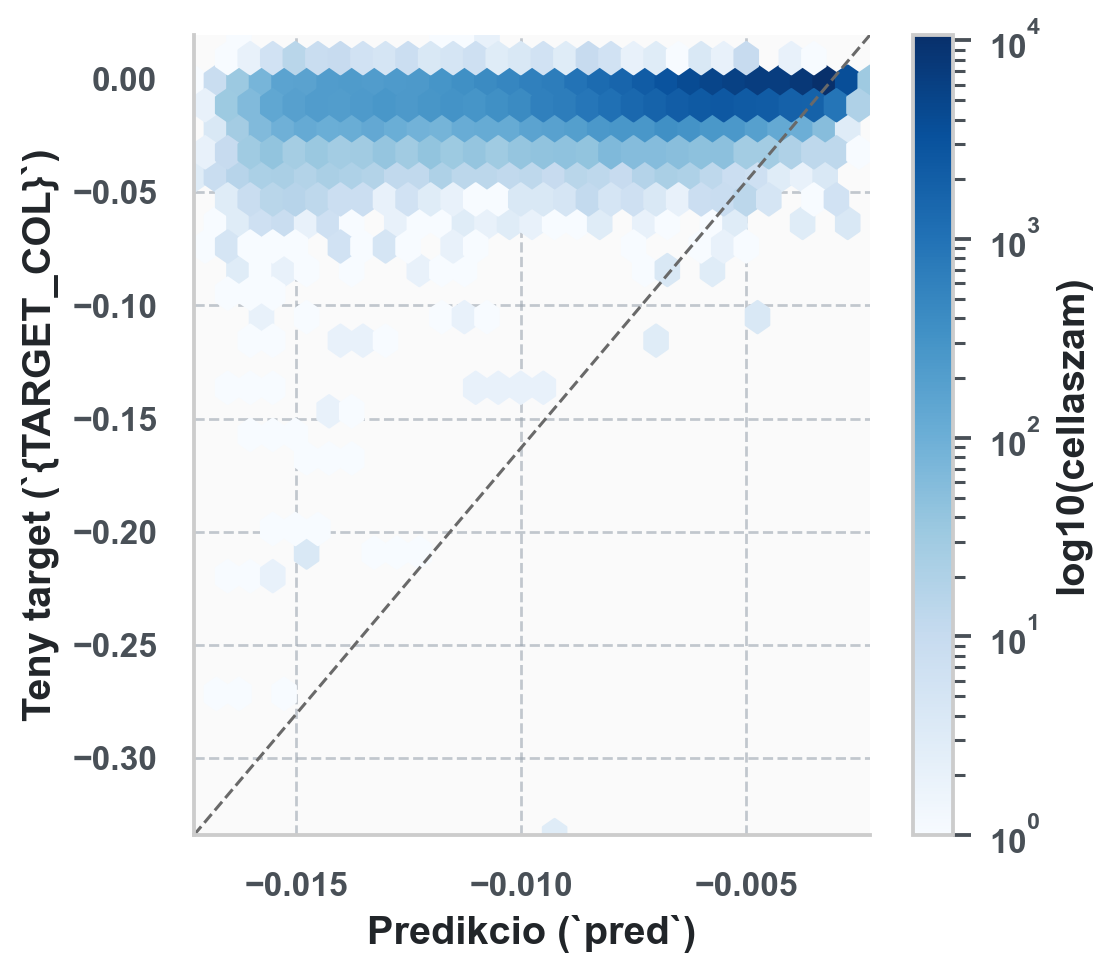

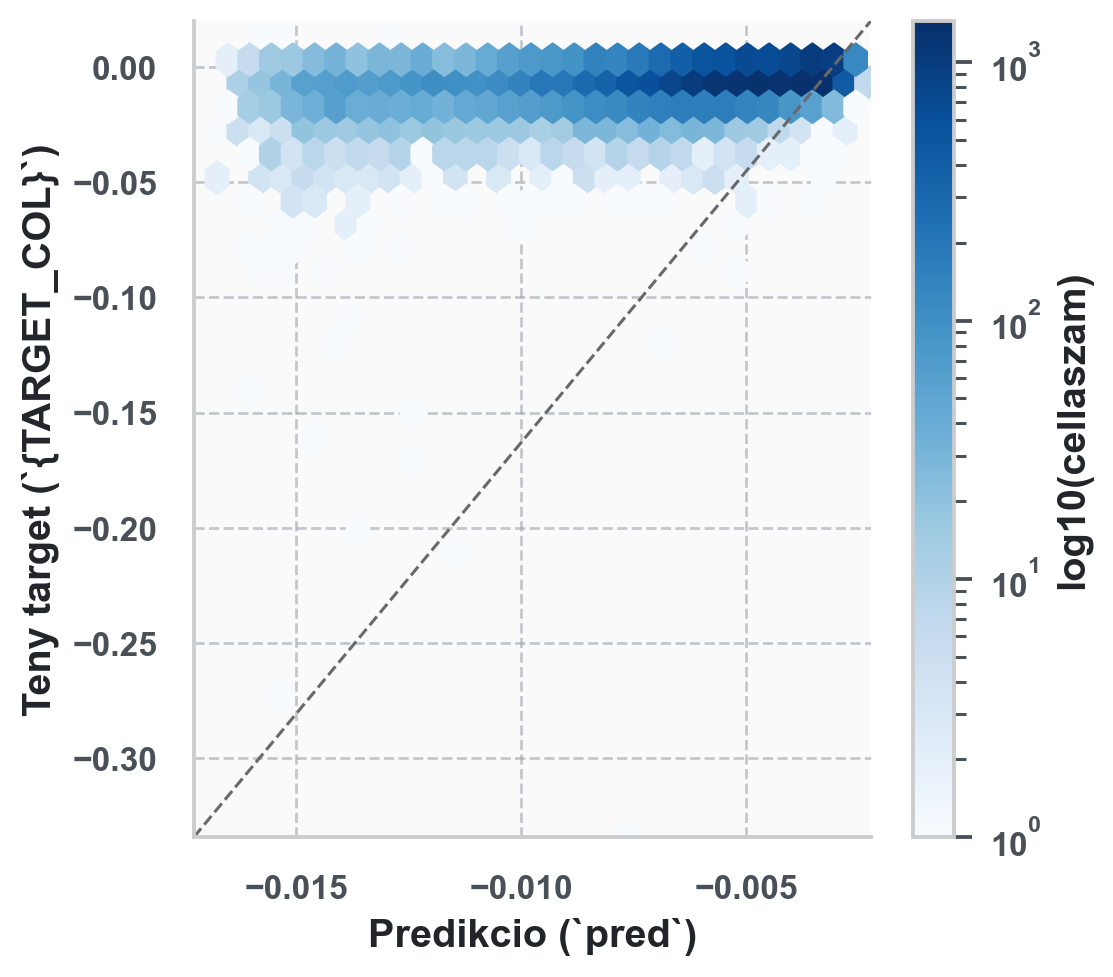

In [12]:
#| label: fig-train-valid-density
#| fig-cap: "Predikcio-target suruseg train es valid mintan logaritmikus cellaszinnel"
#| fig-subcap:
#|   - "Train surusegterkep"
#|   - "Valid surusegterkep"
#| layout-ncol: 2

lo_x = float(pred_df["pred"].min())
hi_x = float(pred_df["pred"].max())
lo_y = float(pred_df["target"].min())
hi_y = float(pred_df["target"].max())
for segment in ["train", "valid"]:
    sub = pred_df.loc[pred_df["segment"] == segment]
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    hb = ax.hexbin(sub["pred"], sub["target"], gridsize=30, bins="log", cmap="Blues", mincnt=1)
    ax.plot([lo_x, hi_x], [lo_y, hi_y], linestyle="--", color=CQ_COLORS["gray"], linewidth=1)
    ax.set_xlabel("Predikcio (`pred`)")
    ax.set_ylabel(f"Teny target (`{{TARGET_COL}}`)")
    ax.set_xlim(lo_x, hi_x)
    ax.set_ylim(lo_y, hi_y)
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("log10(cellaszam)")
    plt.tight_layout()
    plt.show()


In [13]:
#| label: tbl-residual-summary
#| tbl-cap: "Residual osszefoglalo train es valid bontasban"

display_analysis_table(residual_df)


segment,resid_mean,resid_std,resid_q05,resid_median,resid_q95
train,-0.000,0.008,-0.007,-0.001,0.011
valid,0.000,0.008,-0.008,-0.001,0.011


## Decilis Es Rangsorolo Ertelmezes

Itt mar nem az a kerdes, hogy pontbecslokent mennyire pontos a modell, hanem az,
hogy a magasabb score tenyleg jobb helyzeteket jelent-e atlagban a teljes 2023-2026
walk-forward idoszakon es foldonkent is.


In [14]:
#| label: tbl-fold-rank-metrics
#| tbl-cap: "Fold-szintu train es valid rank-metrikak"

display_analysis_table(fold_rank_both_df)


segment,fold,rows,top10_lift,spearman_rho,decile_monotonicity
train,1,24068,0.003,0.320,1.000
valid,1,5856,0.004,0.296,1.000
train,2,24044,0.003,0.334,1.000
valid,2,5880,0.003,0.302,0.889
train,3,24116,0.003,0.332,1.000
valid,3,5808,0.003,0.305,1.000
train,4,24096,0.003,0.326,1.000
valid,4,5832,0.003,0.325,1.000


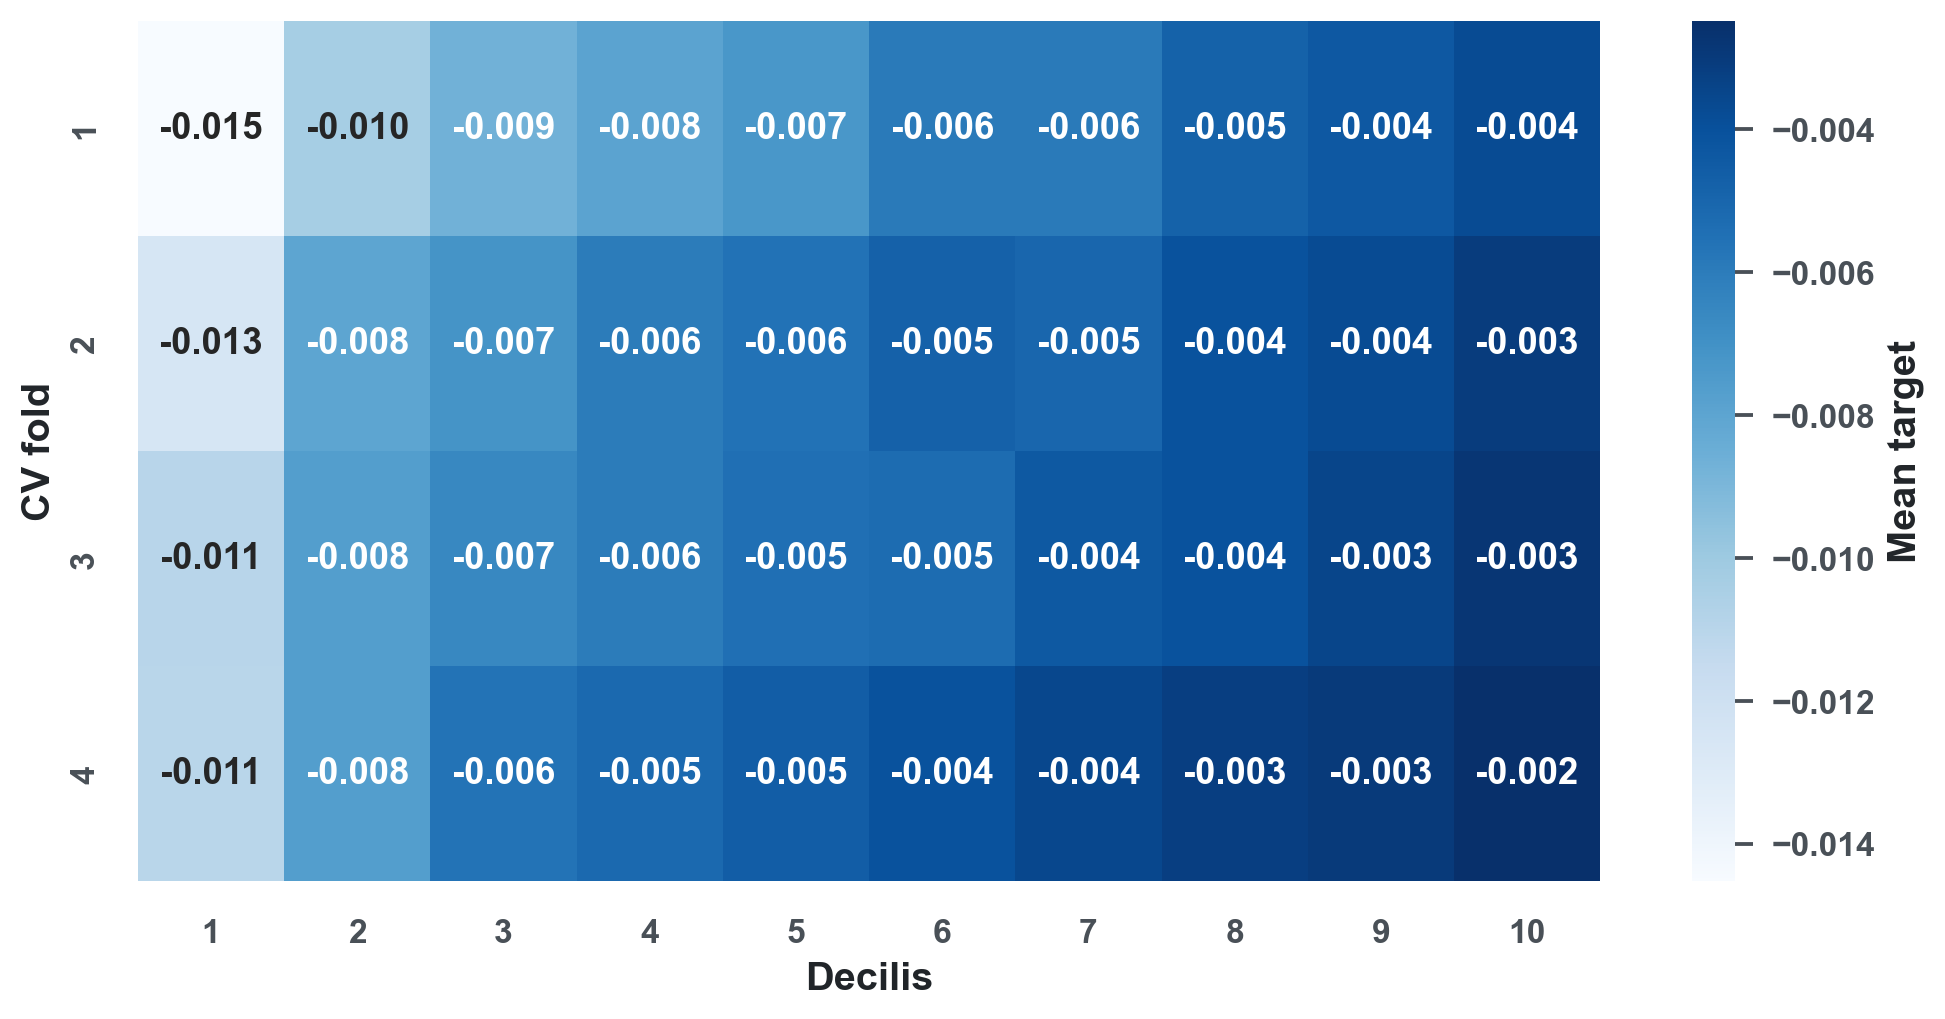

In [15]:
#| label: fig-fold-decile-heatmap
#| fig-cap: "Valid foldok decilisenkenti atlagtargetje"
#| fig-alt: "Heatmap fold x decile szerkezetben."

pivot = valid_fold_decile_df.pivot(index="cv_fold", columns="decile", values="target_mean").sort_index()
fig, ax = plt.subplots(figsize=(9.2, 4.8))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Blues", cbar_kws={"label": "Mean target"}, ax=ax)
ax.set_xlabel("Decilis")
ax.set_ylabel("CV fold")
plt.tight_layout()
plt.show()


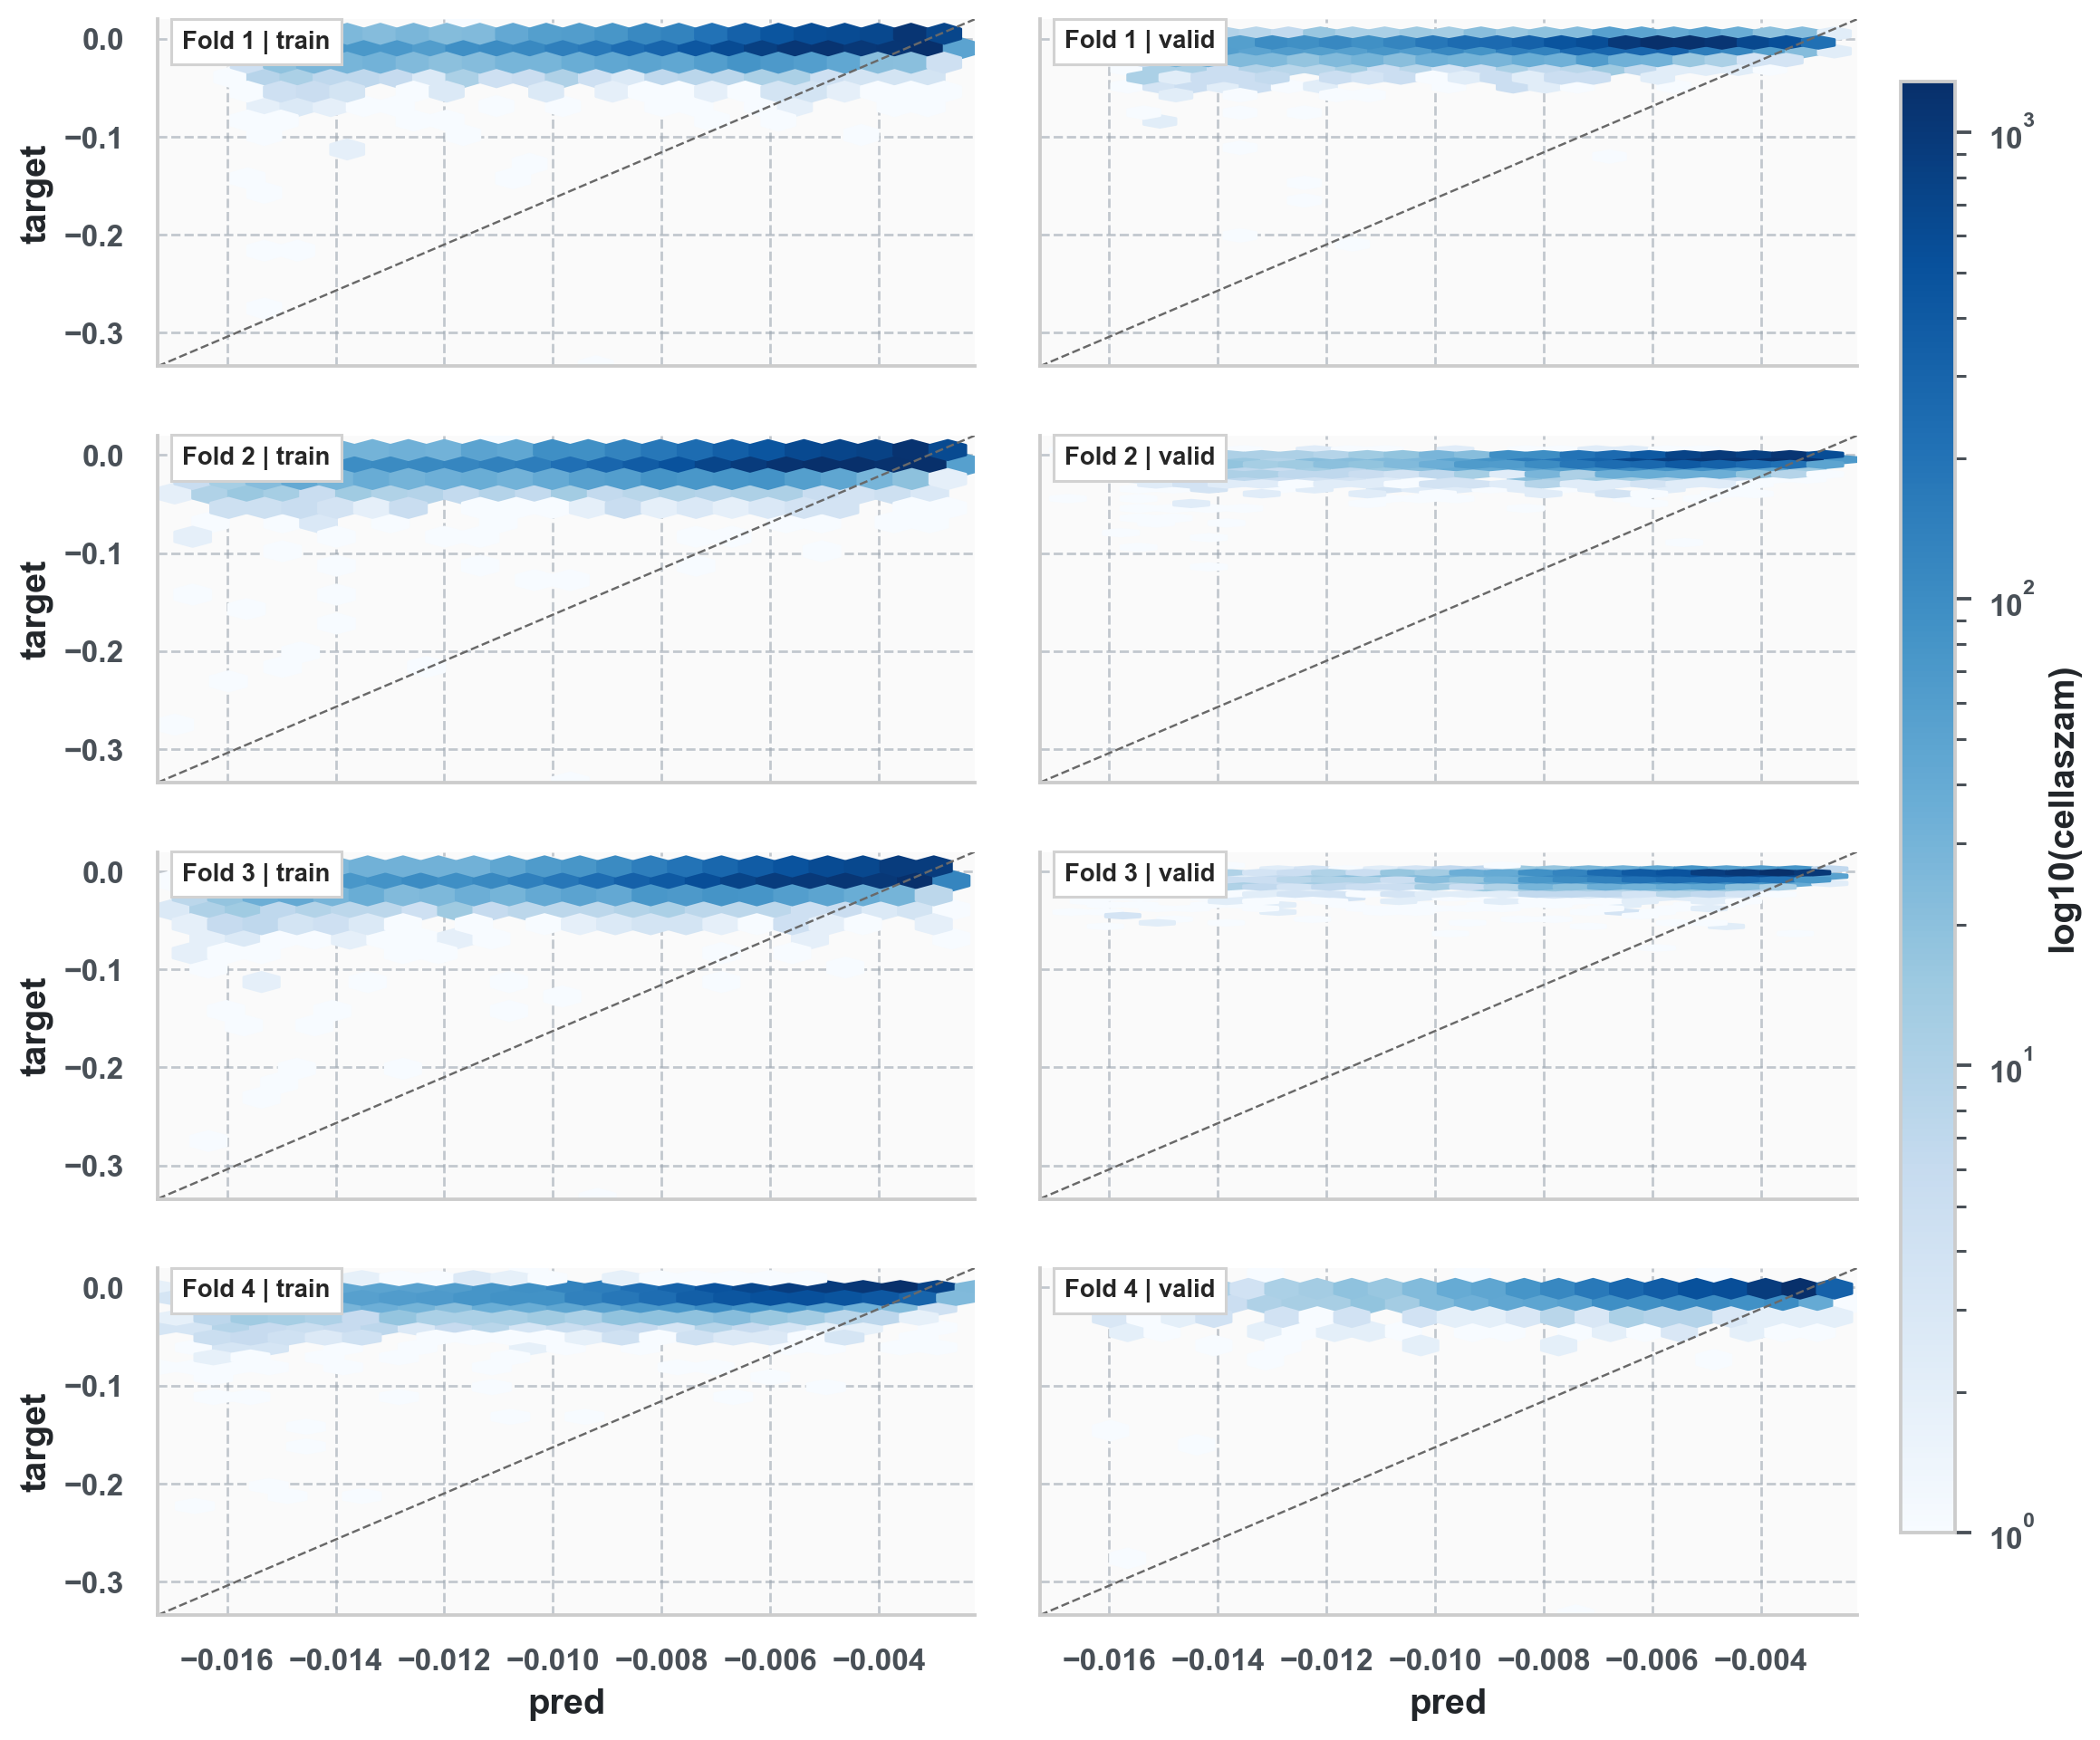

In [16]:
#| label: fig-fold-train-valid-density-grid
#| fig-cap: "Foldonkenti train-valid predikcio-target surusegterkep"
#| fig-alt: "Tobbsoros panel, minden foldhoz train es valid hexbin surusegterkep."

folds = sorted(pred_df["cv_fold"].unique())
fig, axes = plt.subplots(len(folds), 2, figsize=(11, 2.6 * len(folds)), sharex=True, sharey=True)
lo_x = float(pred_df["pred"].min())
hi_x = float(pred_df["pred"].max())
lo_y = float(pred_df["target"].min())
hi_y = float(pred_df["target"].max())
last_hb = None
for row_idx, fold in enumerate(folds):
    for col_idx, segment in enumerate(["train", "valid"]):
        ax = axes[row_idx, col_idx] if len(folds) > 1 else axes[col_idx]
        sub = pred_df.loc[(pred_df["cv_fold"] == fold) & (pred_df["segment"] == segment)]
        last_hb = ax.hexbin(sub["pred"], sub["target"], gridsize=22, bins="log", cmap="Blues", mincnt=1)
        ax.plot([lo_x, hi_x], [lo_y, hi_y], linestyle="--", color=CQ_COLORS["gray"], linewidth=0.8)
        ax.set_xlim(lo_x, hi_x)
        ax.set_ylim(lo_y, hi_y)
        ax.text(0.03, 0.97, f"Fold {fold} | {segment}", transform=ax.transAxes, va="top", ha="left", fontsize=9, bbox={"facecolor": "white", "edgecolor": CQ_COLORS["gray_light"], "pad": 4})
        if row_idx == len(folds) - 1:
            ax.set_xlabel("pred")
        if col_idx == 0:
            ax.set_ylabel("target")
fig.subplots_adjust(right=0.90, wspace=0.08, hspace=0.20)
cax = fig.add_axes([0.92, 0.15, 0.025, 0.70])
fig.colorbar(last_hb, cax=cax, label="log10(cellaszam)")
plt.show()


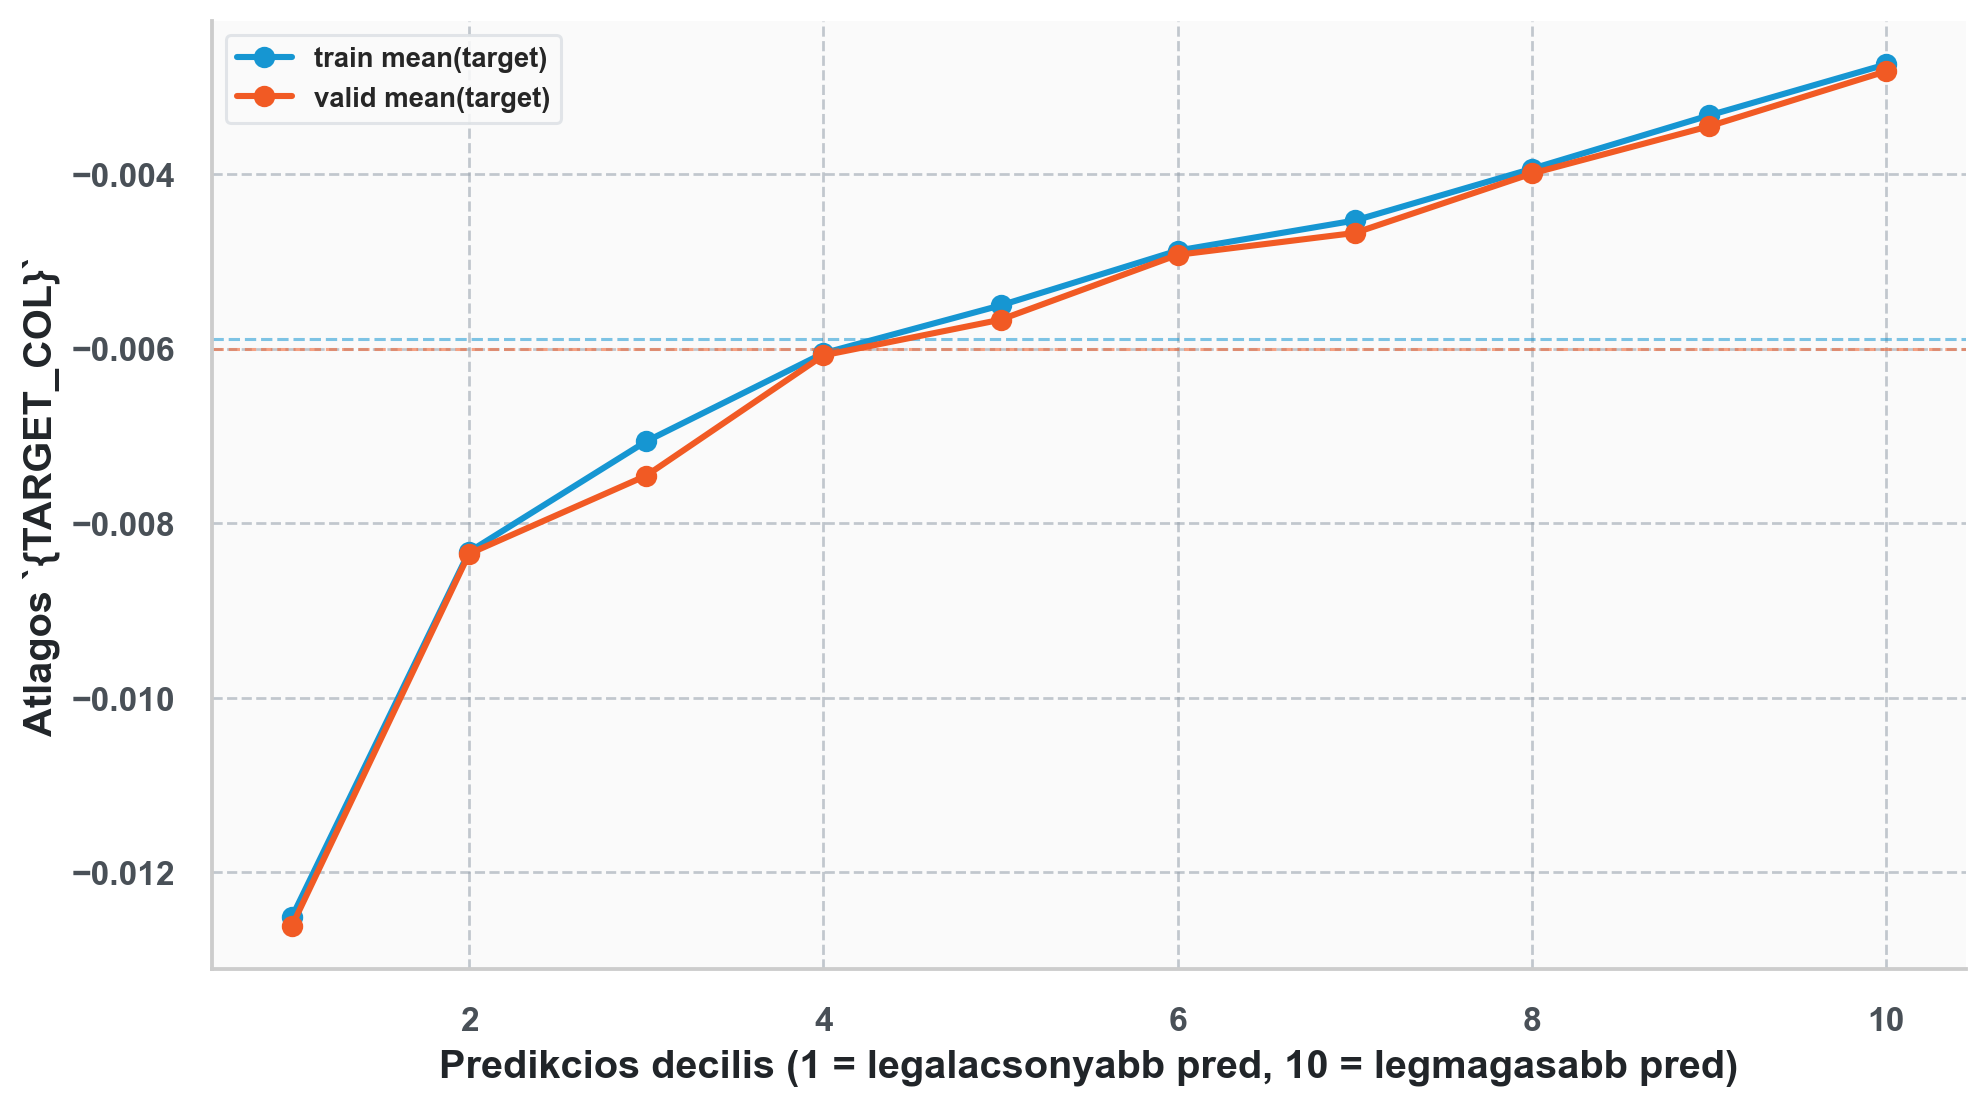

In [17]:
#| label: fig-decile-target-by-segment
#| fig-cap: "Decilisenkenti tenyleges atlagtarget train es valid mintan"
#| fig-alt: "Ket vonaldiagram a mean target ertekekkel decilis szerint."

fig, ax = plt.subplots(figsize=(9.2, 5.2))
for segment in ["train", "valid"]:
    sub = decile_df.loc[decile_df["segment"] == segment].sort_values("decile")
    ax.plot(sub["decile"], sub["target_mean"], marker="o", linewidth=2, color=SEGMENT_COLORS[segment], label=f"{segment} mean(target)")
    ax.axhline(float(sub["overall_target_mean"].iloc[0]), linestyle="--", linewidth=1, color=SEGMENT_COLORS[segment], alpha=0.55)
ax.set_xlabel("Predikcios decilis (1 = legalacsonyabb pred, 10 = legmagasabb pred)")
ax.set_ylabel(f"Atlagos `{{TARGET_COL}}`")
ax.legend()
plt.tight_layout()
plt.show()


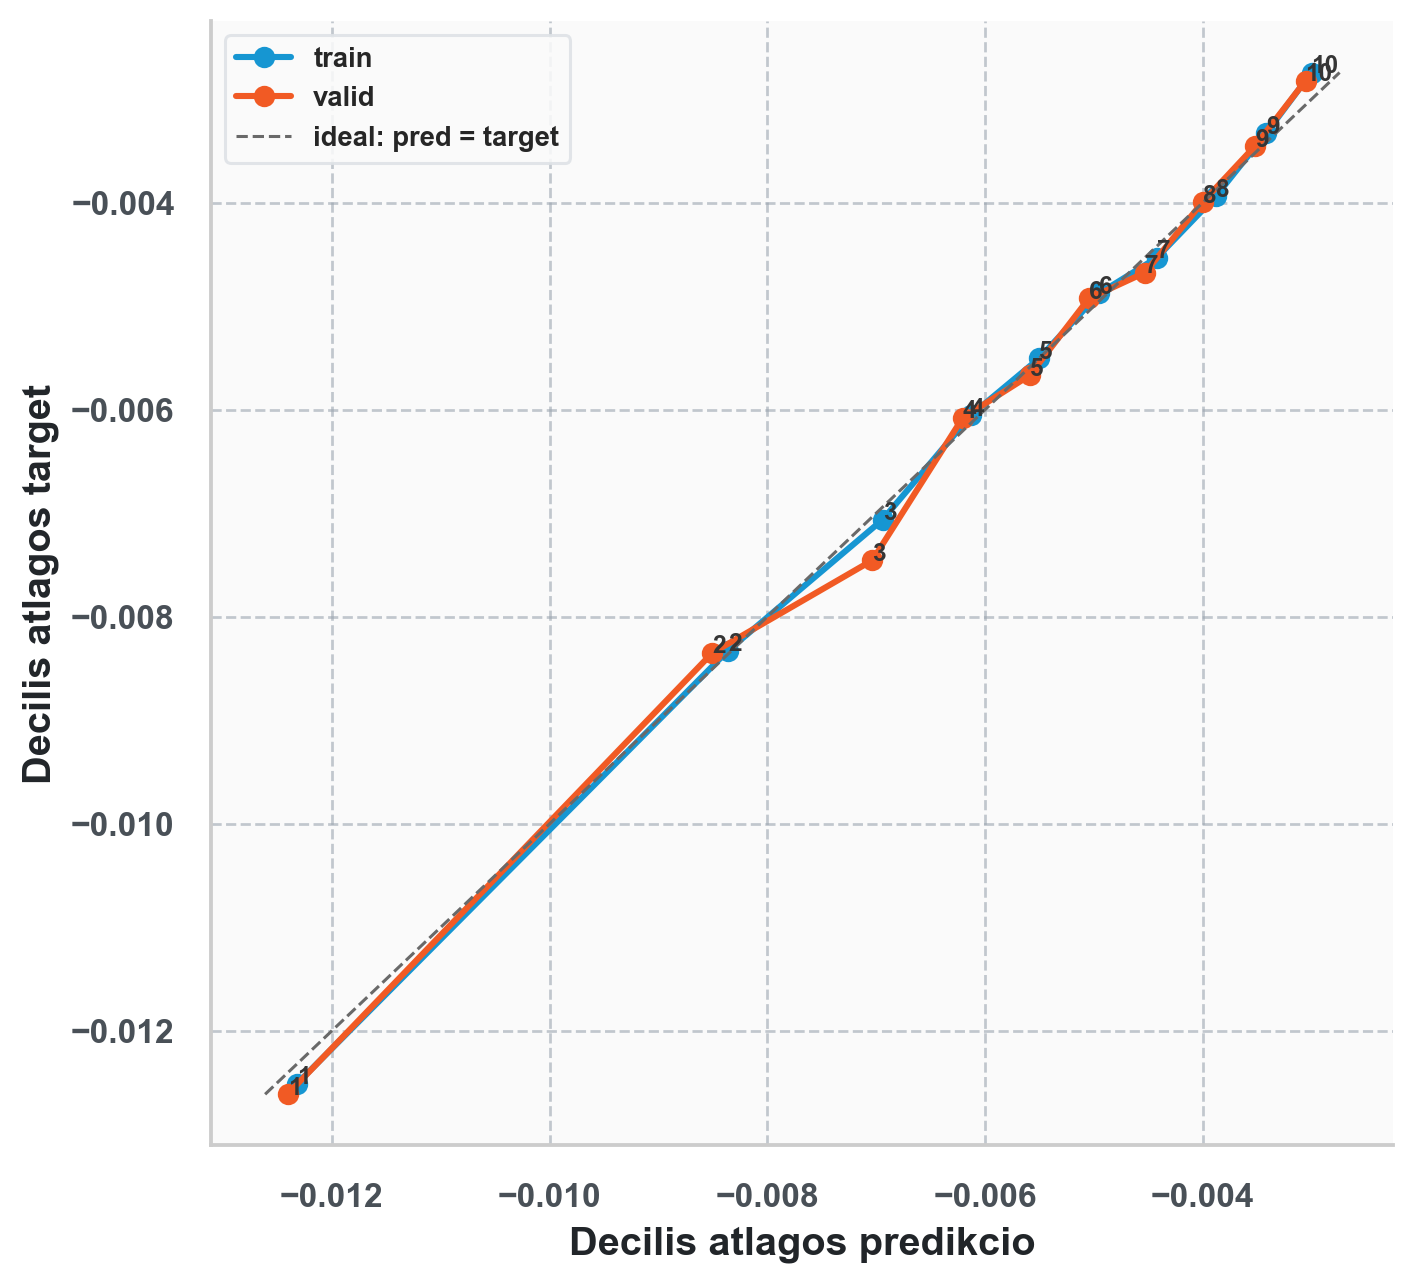

In [18]:
#| label: fig-decile-calibration
#| fig-cap: "Decilis kalibracio: atlagos predikcio vs atlagos target"
#| fig-alt: "Pontdiagram decilisekkel es idealis pred=target atloval."

fig, ax = plt.subplots(figsize=(6.6, 6.0))
lo = float(min(decile_df["pred_mean"].min(), decile_df["target_mean"].min()))
hi = float(max(decile_df["pred_mean"].max(), decile_df["target_mean"].max()))
for segment in ["train", "valid"]:
    sub = decile_df.loc[decile_df["segment"] == segment].sort_values("decile")
    ax.plot(sub["pred_mean"], sub["target_mean"], marker="o", linewidth=2, color=SEGMENT_COLORS[segment], label=segment)
    for _, row in sub.iterrows():
        ax.text(row["pred_mean"], row["target_mean"], str(int(row["decile"])), fontsize=8, color=CQ_COLORS["gray_dark"])
ax.plot([lo, hi], [lo, hi], linestyle="--", color=CQ_COLORS["gray"], linewidth=1, label="ideal: pred = target")
ax.set_xlabel("Decilis atlagos predikcio")
ax.set_ylabel("Decilis atlagos target")
ax.legend()
plt.tight_layout()
plt.show()


In [19]:
#| label: tbl-decile-comparison
#| tbl-cap: "Train-valid decilis osszehasonlitas"

display_analysis_table(comp_df[["decile", "pred_mean_train", "pred_mean_valid", "target_mean_train", "target_mean_valid", "target_mean_valid_minus_train"]])


decile,pred_mean_train,pred_mean_valid,target_mean_train,target_mean_valid,target_mean_valid_minus_train
1,-0.012,-0.012,-0.013,-0.013,-0.000
2,-0.008,-0.009,-0.008,-0.008,-0.000
3,-0.007,-0.007,-0.007,-0.007,-0.000
4,-0.006,-0.006,-0.006,-0.006,-0.000
5,-0.006,-0.006,-0.006,-0.006,-0.000
6,-0.005,-0.005,-0.005,-0.005,-0.000
7,-0.004,-0.005,-0.005,-0.005,-0.000
8,-0.004,-0.004,-0.004,-0.004,-0.000
9,-0.003,-0.004,-0.003,-0.003,-0.000
10,-0.003,-0.003,-0.003,-0.003,-0.000


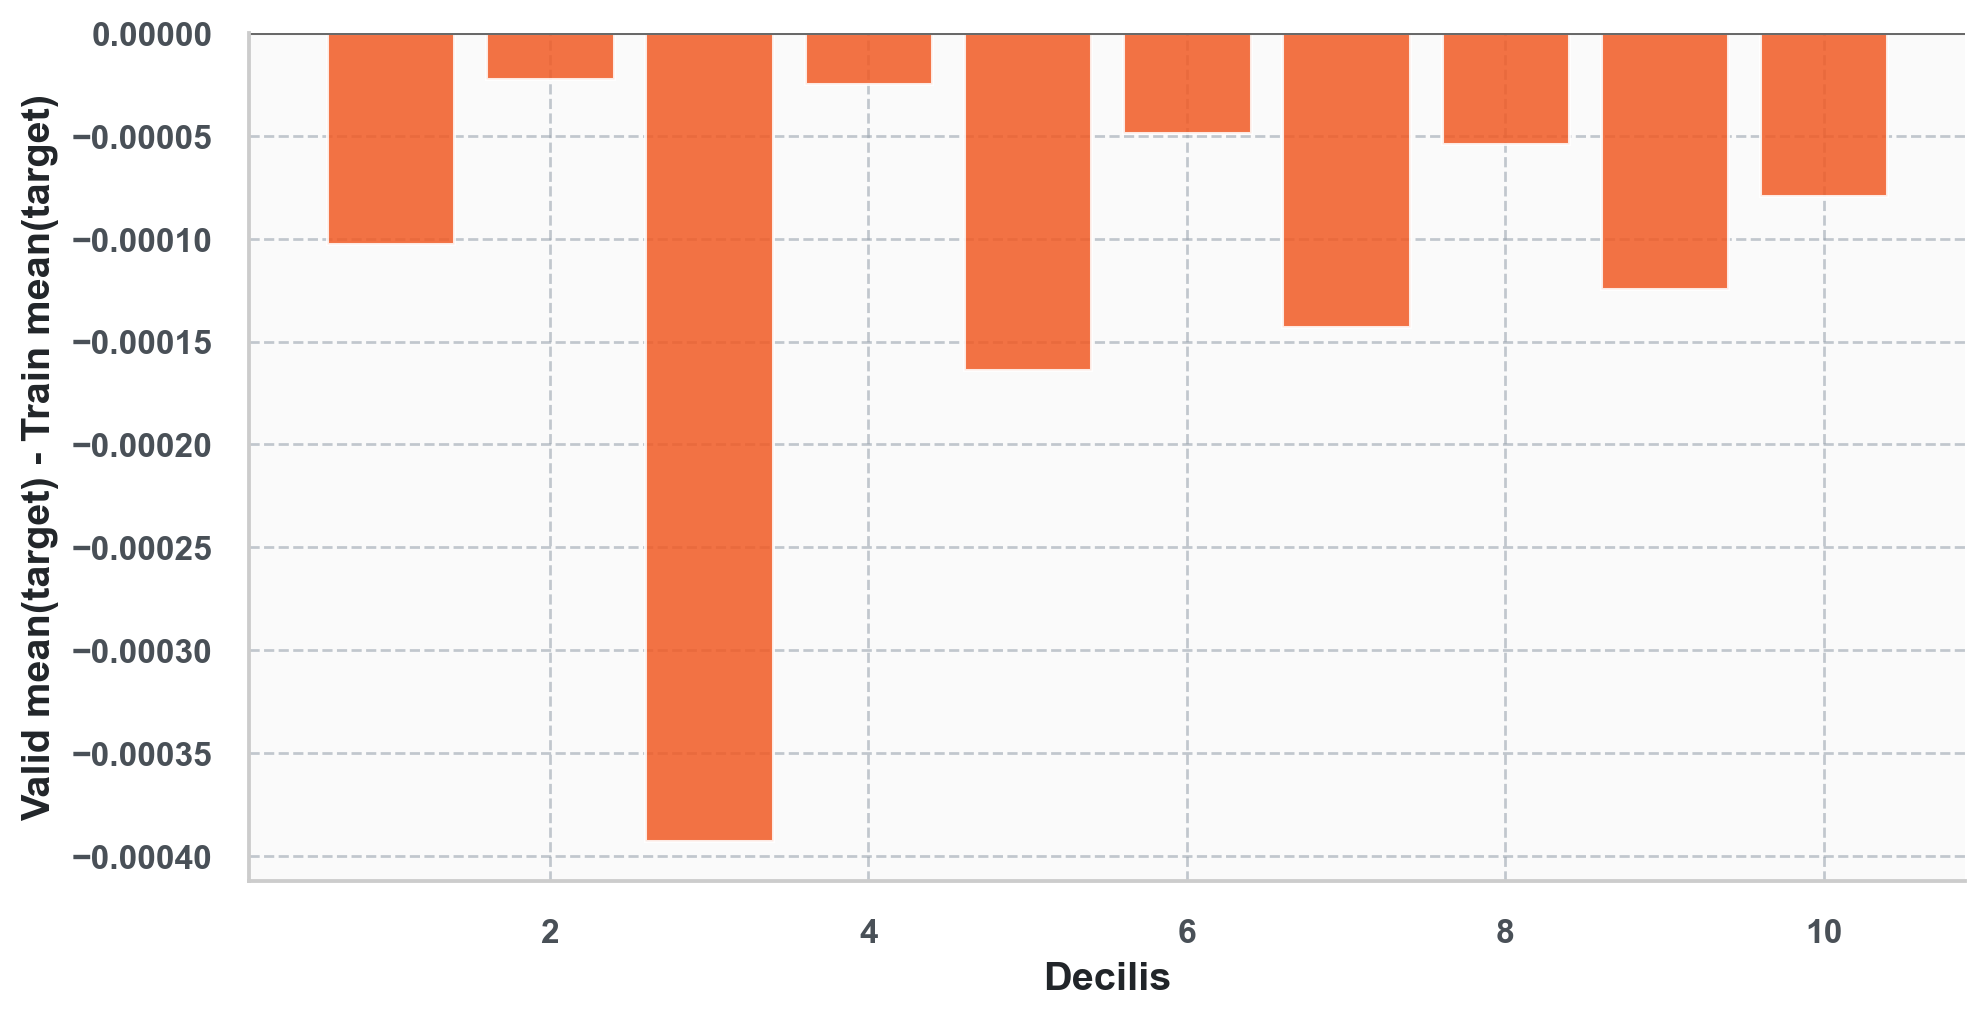

In [20]:
#| label: fig-decile-gap
#| fig-cap: "Valid es train decilisek kozotti target-kulonbseg"
#| fig-alt: "Oszlopdiagram a valid-train mean target kulonbseggel."

fig, ax = plt.subplots(figsize=(9.2, 4.8))
diff = comp_df["target_mean_valid_minus_train"]
colors = np.where(diff >= 0, CQ_COLORS["blue"], CQ_COLORS["orange"])
ax.bar(comp_df["decile"], diff, color=colors, alpha=0.85)
ax.axhline(0, color=CQ_COLORS["gray"], linewidth=1)
ax.set_xlabel("Decilis")
ax.set_ylabel("Valid mean(target) - Train mean(target)")
plt.tight_layout()
plt.show()


In [21]:
#| label: tbl-decile-monotonicity
#| tbl-cap: "Decilis monotonicity es top-bottom spread train es valid mintan"

display_analysis_table(mono_df)


segment,monotonic_pairs,adjacent_pairs,decile_monotonicity,top_minus_bottom,top_div_bottom
train,9,9,1.000,0.010,0.219
valid,9,9,1.000,0.010,0.224


In [22]:
#| label: tbl-top-bottom-ratio
#| tbl-cap: "Elso es tizedik decilis tenyleges target-atlaganak aranya"

display_analysis_table(top_bottom_df[["segment", "bottom_decile_target", "top_decile_target", "top_minus_bottom", "top_div_bottom"]])


segment,bottom_decile_target,top_decile_target,top_minus_bottom,top_div_bottom
train,-0.013,-0.003,0.010,0.219
valid,-0.013,-0.003,0.010,0.224


In [23]:
#| label: tbl-train-decile-summary
#| tbl-cap: "Train decilis summary a teljes minta atlagahoz viszonyitva"

display_analysis_table(train_decile_summary_df)


bucket,rows,pred_mean,target_mean,target_vs_all_abs,target_vs_all_ratio
ALL,96324,-0.006,-0.006,0.000,1.00%
D1,9633,-0.012,-0.013,-0.007,2.13%
D2,9632,-0.008,-0.008,-0.002,1.41%
D3,9632,-0.007,-0.007,-0.001,1.20%
D4,9633,-0.006,-0.006,-0.000,1.03%
D5,9632,-0.006,-0.006,0.000,0.93%
D6,9632,-0.005,-0.005,0.001,0.83%
D7,9633,-0.004,-0.005,0.001,0.77%
D8,9632,-0.004,-0.004,0.002,0.67%
D9,9632,-0.003,-0.003,0.003,0.57%


In [24]:
#| label: tbl-valid-decile-summary
#| tbl-cap: "Valid decilis summary a teljes minta atlagahoz viszonyitva"

display_analysis_table(valid_decile_summary_df)


bucket,rows,pred_mean,target_mean,target_vs_all_abs,target_vs_all_ratio
ALL,23376,-0.006,-0.006,0.000,1.00%
D1,2338,-0.012,-0.013,-0.007,2.10%
D2,2338,-0.009,-0.008,-0.002,1.39%
D3,2337,-0.007,-0.007,-0.001,1.24%
D4,2338,-0.006,-0.006,-0.000,1.01%
D5,2337,-0.006,-0.006,0.000,0.94%
D6,2338,-0.005,-0.005,0.001,0.82%
D7,2337,-0.005,-0.005,0.001,0.78%
D8,2338,-0.004,-0.004,0.002,0.67%
D9,2337,-0.004,-0.003,0.003,0.58%


In [25]:
#| label: final-interpretation
#| echo: false

valid_row = split_metrics_df.loc[split_metrics_df["segment"] == "valid"].iloc[0]
train_row = split_metrics_df.loc[split_metrics_df["segment"] == "train"].iloc[0]
valid_mono = mono_df.loc[mono_df["segment"] == "valid"].iloc[0]
train_mono = mono_df.loc[mono_df["segment"] == "train"].iloc[0]
valid_d10 = valid_decile_summary_df.loc[valid_decile_summary_df["bucket"] == "D10"].iloc[0]
weakest_fold = fold_metrics_df.sort_values("valid_r2").iloc[0]
strongest_fold = fold_metrics_df.sort_values("valid_r2", ascending=False).iloc[0]

bullets = [
    f"A valid oldali `R2 = {valid_row['r2']:.3f}` es `corr = {valid_row['corr']:.3f}` azt mutatja, hogy a modellben van jel, de a target tovabbra is zajos.",
    f"A train-valid hiba kozel marad egymashoz (`RMSE {train_row['rmse']:.4f}` vs `{valid_row['rmse']:.4f}`), vagyis nincs eros overfit-jel a teljes walk-forward futasban.",
    f"A decilis rangsor stabil: train monotonicity `{train_mono['decile_monotonicity']:.2%}`, valid monotonicity `{valid_mono['decile_monotonicity']:.2%}`.",
    f"Validon a `D10` target-atlag kb. `{valid_d10['target_vs_all_ratio']:.2f}x` a teljes valid atlaghoz kepest, ami a score hasznalhatosagat tamasztja ala.",
    f"A legerosebb valid fold `Fold {int(strongest_fold['fold'])}`, a leggyengebb `Fold {int(weakest_fold['fold'])}`, tehat a modell teljesitmenye rezsimfuggo, de nem esik szet a kesobbi 2025-2026 szakaszban sem.",
    "A modell ezert inkabb rangsorolo score-kent eros, mint pontos abszolut pontbecslokent.",
]
display(Markdown("## Vegso Ertelmezes\n\n" + "\n".join(f"- {x}" for x in bullets)))


## Vegso Ertelmezes

- A valid oldali `R2 = 0.123` es `corr = 0.351` azt mutatja, hogy a modellben van jel, de a target tovabbra is zajos.
- A train-valid hiba kozel marad egymashoz (`RMSE 0.0076` vs `0.0076`), vagyis nincs eros overfit-jel a teljes walk-forward futasban.
- A decilis rangsor stabil: train monotonicity `100.00%`, valid monotonicity `100.00%`.
- Validon a `D10` target-atlag kb. `0.47x` a teljes valid atlaghoz kepest, ami a score hasznalhatosagat tamasztja ala.
- A legerosebb valid fold `Fold 2`, a leggyengebb `Fold 4`, tehat a modell teljesitmenye rezsimfuggo, de nem esik szet a kesobbi 2025-2026 szakaszban sem.
- A modell ezert inkabb rangsorolo score-kent eros, mint pontos abszolut pontbecslokent.